In [ ]:
import pytensor
import warnings
import numba
pytensor.config.mode = "NUMBA"
warnings.filterwarnings("ignore", category=numba.NumbaPerformanceWarning)
import time
import numpy as np

import pymc as pm
import arviz as az

import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2

In [2]:
def simulate_problem(N, D):
    sigma_noise = 20000

    def build_model(X, y=None):
        with pm.Model() as model:
            w = pm.Normal(
                "w", 
                mu=np.array([150.] + [0.] * (D - 1)), 
                sigma=np.array([100.] * D)
            )
            mu = pm.math.dot(X, w)
            pm.Normal("obs", mu=mu, sigma=sigma_noise, observed=y)
    
        return model
    
    np.random.seed(0)
    x = np.hstack(
        [
            np.random.uniform(500, 2500, N).reshape(-1, 1),
            np.random.uniform(0, 100, size=(N, D - 1)),
        ]
    )
    true_w = np.array([200] + [0] * (D - 1))
    noise = np.random.normal(0, sigma_noise, size=N)
    y = x @ true_w + noise

    t0 = time.perf_counter()
    with build_model(x, y):
        mcmc_samples = pm.sample(random_seed=0)
    return time.perf_counter() - t0

In [3]:
# N = 20
N = 1000
D = 1
# D = 50

simulate_problem(N, D)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 14 seconds.


36.141906292003114

In [4]:
N = 1000
D = 50

simulate_problem(N, D)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 21 seconds.


21.630509250004252

In [6]:
# N = 10_000
N = 1000
D = 100
# D = 50

simulate_problem(N, D)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 29 seconds.


28.93382245900284

In [12]:
def simulate_problem_vi(N, D, num_steps):
    sigma_noise = 20000

    def build_model(X, y=None):
        if y is None:
            X = pm.Minibatch(X, batch_size=50)
        else:
            X, y = pm.Minibatch(X, y, batch_size=50)
        with pm.Model() as model:
            w = pm.Normal(
                "w", 
                mu=np.array([150.] + [0.] * (D - 1)), 
                sigma=np.array([100.] * D)
            )
            mu = pm.math.dot(X, w)
            pm.Normal("obs", mu=mu, sigma=sigma_noise, observed=y)
    
        return model
    
    np.random.seed(0)
    x = np.hstack(
        [
            np.random.uniform(500, 2500, N).reshape(-1, 1),
            np.random.uniform(0, 100, size=(N, D - 1)),
        ]
    )
    true_w = np.array([200] + [0] * (D - 1))
    noise = np.random.normal(0, sigma_noise, size=N)
    y = x @ true_w + noise

    t0 = time.perf_counter()
    with build_model(x, y):
        vi_approx = pm.fit(n=num_steps)
        vi_samples = vi_approx.sample(4000, random_seed=0)
    plt.plot(vi_approx.hist)
    plt.show()
    return time.perf_counter() - t0

/Users/quannguyen/anaconda3/envs/gb/lib/python3.10/site-packages/pymc/model/core.py:1238: UserWarning: total_size not provided for observed variable `obs` that uses pm.Minibatch
  warnings.warn(


/Users/quannguyen/anaconda3/envs/gb/lib/python3.10/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Finished [100%]: Average Loss = 580.55


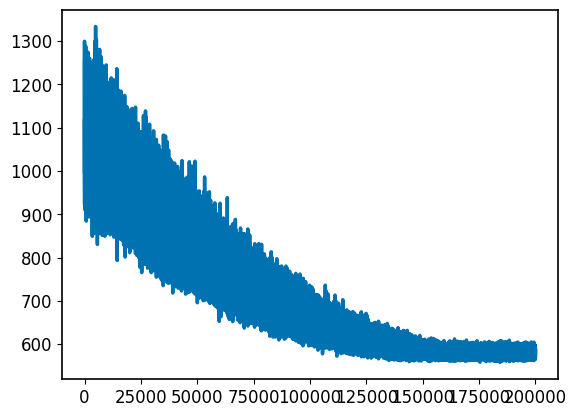

9.322654666000744

In [16]:
N = 20
D = 1

simulate_problem_vi(N, D, 200_000)

/Users/quannguyen/anaconda3/envs/gb/lib/python3.10/site-packages/pymc/model/core.py:1238: UserWarning: total_size not provided for observed variable `obs` that uses pm.Minibatch
  warnings.warn(


/Users/quannguyen/anaconda3/envs/gb/lib/python3.10/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Finished [100%]: Average Loss = 626.06


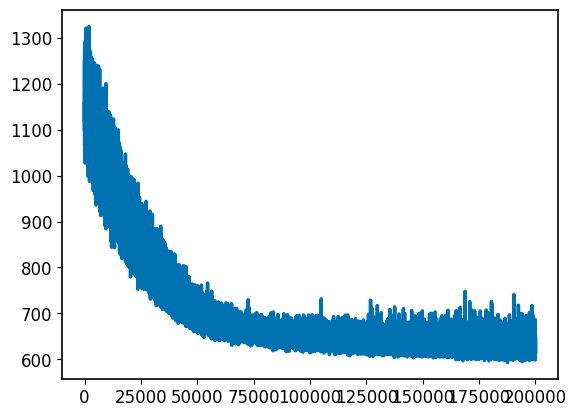

10.119967999999062

In [14]:
N = 1000
D = 50

simulate_problem_vi(N, D, 200_000)

/Users/quannguyen/anaconda3/envs/gb/lib/python3.10/site-packages/pymc/model/core.py:1238: UserWarning: total_size not provided for observed variable `obs` that uses pm.Minibatch
  warnings.warn(


/Users/quannguyen/anaconda3/envs/gb/lib/python3.10/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Finished [100%]: Average Loss = 677.85


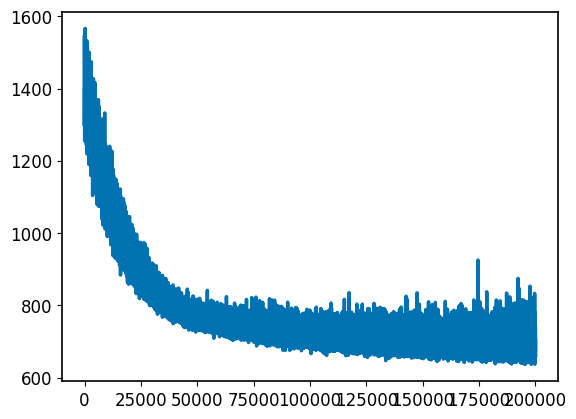

11.234957542001212

In [15]:
N = 10_000
D = 100

simulate_problem_vi(N, D, 200_000)